<a href="https://colab.research.google.com/github/Aditipujari10/Deep_Learning_Lab/blob/main/DL_EXP_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize data (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels to categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training shape:", x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training shape: (50000, 32, 32, 3)


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_frozen = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 301s 185ms/step - accuracy: 0.0976 - loss: 2.3111 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 292s 166ms/step - accuracy: 0.0987 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 267s 169ms/step - accuracy: 0.0995 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 263s 168ms/step - accuracy: 0.0993 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 321s 168ms/step - accuracy: 0.0991 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3027


In [ ]:
loss_frozen, acc_frozen = model.evaluate(x_test, y_test)
print("Frozen Model Accuracy:", acc_frozen)

313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 133ms/step - accuracy: 0.1000 - loss: 2.3027
Frozen Model Accuracy: 0.10000000149011612


In [ ]:
for layer in base_model.layers[-10:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
loss_ft, acc_ft = model.evaluate(x_test, y_test)
print("Fine-Tuned Model Accuracy:", acc_ft)

313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 137ms/step - accuracy: 0.1000 - loss: 2.3027
Fine-Tuned Model Accuracy: 0.10000000149011612


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 713s 449ms/step - accuracy: 0.2476 - loss: 2.0583 - val_accuracy: 0.2221 - val_loss: 2.1907
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 688s 440ms/step - accuracy: 0.3755 - loss: 1.7927 - val_accuracy: 0.2067 - val_loss: 2.4320
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 699s 447ms/step - accuracy: 0.4176 - loss: 1.6827 - val_accuracy: 0.2608 - val_loss: 2.4462
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 733s 441ms/step - accuracy: 0.4475 - loss: 1.6112 - val_accuracy: 0.3396 - val_loss: 1.8625
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 752s 447ms/step - accuracy: 0.4659 - loss: 1.5606 - val_accuracy: 0.2847 - val_loss: 2.1183


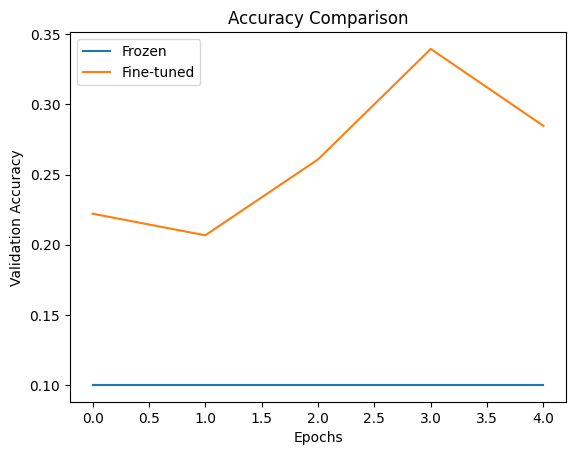

In [ ]:
history_finetune = model.fit(
    x_train, y_train,
    epochs=5, # You can adjust the number of epochs for fine-tuning
    validation_data=(x_test, y_test)
)

plt.plot(history_frozen.history['val_accuracy'], label='Frozen')
plt.plot(history_finetune.history['val_accuracy'], label='Fine-tuned')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()